# So sánh baseline tuyến tính/phi-deep trên đặc trưng âm học thô vs. mô hình Phase 2

Notebook này KHÔNG huấn luyện lại backbone. Mục tiêu: kiểm tra xem độ chính xác
A/T/S (Activation/Tension/Stability) của Phase 2 có thực sự vượt trội so với một
baseline rất đơn giản (Logistic Regression / Gradient Boosting) được huấn luyện
trực tiếp trên các đặc trưng vô hướng (e_mean, e_cv, pause_ratio, z_mean, z_std,
f0_range_rel, f0_motion_rel, log_energy) — đây chính là các thành phần dùng để
xây công thức nhãn proxy A/T/S.

Logic: nếu baseline phi-deep này đạt độ chính xác gần bằng Phase 2, phần đóng góp
"representation learning" của đề tài cần được trình bày lại, tập trung vào hình
học embedding (state margin, pair similarity) thay vì độ chính xác phân loại.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q numpy pandas scipy torch tqdm scikit-learn matplotlib seaborn easydict

Mounted at /content/drive


In [2]:
import json
import math
import warnings
from pathlib import Path
from typing import Dict, Any, List

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

warnings.filterwarnings('ignore')

In [3]:
DRIVE_ROOT = Path('/content/drive/MyDrive')

LOCAL_DATA_ROOT = Path('/content/processed_v10_safe')
DRIVE_DATA_ROOT = DRIVE_ROOT / 'data/processed_v10_safe'
DATA_ROOT = LOCAL_DATA_ROOT if (LOCAL_DATA_ROOT / 'all_metadata.csv').exists() else DRIVE_DATA_ROOT

METADATA_PATH = DATA_ROOT / 'all_metadata.csv'
PRECOMPUTED_DIR = DATA_ROOT / 'precomputed'

# Threshold đã được Phase2_final.ipynb tính trên TRAIN và lưu lại.
# Dùng lại file này để nhãn baseline 100% giống nhãn dùng huấn luyện/đánh giá Phase 2.
PHASE2_EVAL_DIR = DRIVE_ROOT / 'motionemo_v10_phase2' / 'eval'
STATE_THRESHOLDS_PATH = PHASE2_EVAL_DIR / 'state_thresholds.json'

# Dự đoán Phase 2 đã lưu sẵn (từ extract_phase2_outputs trong Phase2_final.ipynb)
PHASE2_FINAL_EVAL_DIR = PHASE2_EVAL_DIR / 'final_eval'
PHASE2_TEST_PRED_PATH = PHASE2_FINAL_EVAL_DIR / 'test_predictions.csv'
PHASE2_VAL_PRED_PATH = PHASE2_FINAL_EVAL_DIR / 'val_predictions.csv'

OUTPUT_ROOT = DRIVE_ROOT / 'motionemo_v10_raw_baseline'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

STATE_NAMES = ['activation', 'tension', 'stability']
STATE_LABEL_NAMES = ['low', 'mid', 'high']

assert METADATA_PATH.exists(), f'Metadata not found: {METADATA_PATH}'
assert STATE_THRESHOLDS_PATH.exists(), (
    f'Threshold file not found: {STATE_THRESHOLDS_PATH}. '
    'Hãy chạy Phase2_final.ipynb (hoặc ít nhất phần compute_or_load_state_thresholds) trước.'
)

with open(STATE_THRESHOLDS_PATH, 'r', encoding='utf-8') as f:
    STATE_THRESHOLDS = json.load(f)

print('Loaded thresholds:', json.dumps(STATE_THRESHOLDS, indent=2))

df = pd.read_csv(METADATA_PATH)
df['feature_path'] = df['feature_path'].apply(lambda p: str(PRECOMPUTED_DIR / Path(p).name))

train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df = df[df['split'] == 'val'].reset_index(drop=True)
test_df = df[df['split'] == 'test'].reset_index(drop=True)

# Audit lại speaker-disjoint (giống các notebook khác) trước khi dùng split.
for a, b in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    A = set(df[df['split'] == a]['speaker_uid'])
    B = set(df[df['split'] == b]['speaker_uid'])
    overlap = A & B
    print(f'Speaker overlap {a}/{b}: {len(overlap)}')
    if overlap:
        raise RuntimeError(f'Speaker leakage detected: {a}/{b}')

print('Train/Val/Test sizes:', len(train_df), len(val_df), len(test_df))

# ============================================================
# CELL: code (hàm tính descriptor thô — bản mở rộng của
# compute_vocal_state_scores_from_arrays trong Phase2_final.ipynb)
# ============================================================

def _to_np(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def compute_state_scores_and_descriptors(f0_raw, energy_raw, zcr_raw, voiced_mask) -> Dict[str, float]:
    """Giữ NGUYÊN công thức A/T/S gốc (Phase2_final.ipynb), chỉ thêm việc trả về
    các đặc trưng vô hướng trung gian để dùng làm input cho baseline phi-deep.
    Không thay đổi logic tính activation/tension/stability — nhãn vẫn nhất quán
    100% với nhãn đã dùng để huấn luyện/đánh giá Phase 2."""
    f0 = _to_np(f0_raw).astype(np.float32).reshape(-1)
    energy = _to_np(energy_raw).astype(np.float32).reshape(-1)
    zcr = _to_np(zcr_raw).astype(np.float32).reshape(-1)
    voiced = _to_np(voiced_mask).astype(np.float32).reshape(-1) > 0.5

    T = min(len(f0), len(energy), len(zcr), len(voiced))
    empty = {
        'e_mean': 0.0, 'e_cv': 0.0, 'pause_ratio': 0.0,
        'z_mean': 0.0, 'z_std': 0.0,
        'f0_range_rel': 0.0, 'f0_motion_rel': 0.0, 'log_energy': 0.0,
    }
    if T <= 2:
        return {'activation': 0.0, 'tension': 0.0, 'stability': 0.0, **empty}

    f0 = f0[:T]
    energy = np.maximum(energy[:T], 0.0)
    zcr = np.maximum(zcr[:T], 0.0)
    voiced = voiced[:T] & np.isfinite(f0) & (f0 > 0)

    eps = 1e-8
    e_mean = float(np.mean(energy))
    e_std = float(np.std(energy))
    e_p95 = float(np.percentile(energy, 95)) + eps
    e_cv = e_std / (e_mean + eps)

    e_rel = energy / e_p95
    pause_ratio = float(np.mean(e_rel < 0.03))

    z_mean = float(np.mean(zcr))
    z_std = float(np.std(zcr))

    if voiced.sum() > 2:
        vf0 = f0[voiced]
        f0_mean = float(np.mean(vf0)) + eps
        f0_p10 = float(np.percentile(vf0, 10))
        f0_p90 = float(np.percentile(vf0, 90))
        f0_range_rel = (f0_p90 - f0_p10) / f0_mean
        f0_diff = np.diff(vf0)
        f0_motion_rel = float(np.std(f0_diff)) / f0_mean
    else:
        f0_range_rel = 0.0
        f0_motion_rel = 0.0

    log_energy = math.log(e_mean + 1e-6)

    activation = 0.45 * log_energy + 0.35 * z_mean + 0.20 * f0_range_rel
    tension = 0.45 * f0_motion_rel + 0.35 * e_cv + 0.20 * z_std
    instability = 0.45 * pause_ratio + 0.35 * f0_motion_rel + 0.20 * e_cv
    stability = -instability

    return {
        'activation': float(activation),
        'tension': float(tension),
        'stability': float(stability),
        'e_mean': e_mean,
        'e_cv': e_cv,
        'pause_ratio': pause_ratio,
        'z_mean': z_mean,
        'z_std': z_std,
        'f0_range_rel': f0_range_rel,
        'f0_motion_rel': f0_motion_rel,
        'log_energy': log_energy,
    }


def assign_state_label(score: float, thresholds: List[float]) -> int:
    lo, hi = thresholds
    if score <= lo:
        return 0
    if score <= hi:
        return 1
    return 2


RAW_FEATURE_COLS = [
    'e_mean', 'e_cv', 'pause_ratio', 'z_mean', 'z_std',
    'f0_range_rel', 'f0_motion_rel', 'log_energy',
]

Loaded thresholds: {
  "activation": [
    -1.1789047548920202,
    -1.0910444258413774
  ],
  "tension": [
    0.5080785265271103,
    0.608056457961331
  ],
  "stability": [
    -0.41222898640634226,
    -0.33455883524576263
  ]
}
Speaker overlap train/val: 0
Speaker overlap train/test: 0
Speaker overlap val/test: 0
Train/Val/Test sizes: 6578 1665 1651


In [4]:
def build_raw_descriptor_table(df_split: pd.DataFrame, desc: str = 'split') -> pd.DataFrame:
    rows = []
    for _, row in tqdm(df_split.iterrows(), total=len(df_split), desc=f'Raw descriptors: {desc}'):
        obj = torch.load(row['feature_path'], map_location='cpu', weights_only=False)
        feats = compute_state_scores_and_descriptors(
            obj['f0_raw'], obj['energy_raw'], obj['zcr_raw'], obj['voiced_mask']
        )
        feats['sample_id'] = row['sample_id']
        feats['speaker_uid'] = row['speaker_uid']
        feats['dataset'] = row['dataset']
        for state in STATE_NAMES:
            feats[f'{state}_label'] = assign_state_label(feats[state], STATE_THRESHOLDS[state])
        rows.append(feats)
    return pd.DataFrame(rows)


train_feat = build_raw_descriptor_table(train_df, 'train')
val_feat = build_raw_descriptor_table(val_df, 'val')
test_feat = build_raw_descriptor_table(test_df, 'test')

train_feat.to_csv(OUTPUT_ROOT / 'train_raw_descriptors.csv', index=False)
val_feat.to_csv(OUTPUT_ROOT / 'val_raw_descriptors.csv', index=False)
test_feat.to_csv(OUTPUT_ROOT / 'test_raw_descriptors.csv', index=False)

print('Train/Val/Test descriptor table shapes:', train_feat.shape, val_feat.shape, test_feat.shape)

for state in STATE_NAMES:
    print(state, 'label distribution (test):',
          test_feat[f'{state}_label'].value_counts().sort_index().to_dict())

Raw descriptors: train:   0%|          | 0/6578 [00:00<?, ?it/s]

Raw descriptors: val:   0%|          | 0/1665 [00:00<?, ?it/s]

Raw descriptors: test:   0%|          | 0/1651 [00:00<?, ?it/s]

Train/Val/Test descriptor table shapes: (6578, 17) (1665, 17) (1651, 17)
activation label distribution (test): {0: 512, 1: 572, 2: 567}
tension label distribution (test): {0: 715, 1: 497, 2: 439}
stability label distribution (test): {0: 433, 1: 494, 2: 724}


## Kiểm tra "sanity check" (KHÔNG phải baseline công bằng)

Nếu dùng chính điểm A/T/S tổng hợp (activation/tension/stability) làm input duy
nhất, độ chính xác sẽ gần như tuyệt đối — vì nhãn được lượng tử hoá trực tiếp từ
điểm này. Đây chỉ xác nhận công thức nhãn là tất định, KHÔNG nói lên điều gì về
chất lượng biểu diễn. Không dùng số này để so sánh với Phase 2 trong báo cáo.

In [5]:
print('=' * 70)
print('SANITY CHECK (không phải baseline công bằng — chỉ xác nhận nhãn tất định)')
print('=' * 70)
for state in STATE_NAMES:
    Xtr = train_feat[[state]].values
    ytr = train_feat[f'{state}_label'].values
    Xte = test_feat[[state]].values
    yte = test_feat[f'{state}_label'].values
    clf = LogisticRegression(max_iter=200).fit(Xtr, ytr)
    acc = clf.score(Xte, yte)
    print(f'[SANITY] {state}: test acc on the single aggregate score = {acc:.4f}')

SANITY CHECK (không phải baseline công bằng — chỉ xác nhận nhãn tất định)
[SANITY] activation: test acc on the single aggregate score = 0.9655
[SANITY] tension: test acc on the single aggregate score = 0.9836
[SANITY] stability: test acc on the single aggregate score = 0.9721


## Baseline thật: Logistic Regression & Gradient Boosting trên 8 đặc trưng thô

Đây là phép so sánh có ý nghĩa với Phase 2: cùng split, cùng nhãn, nhưng KHÔNG
dùng mô hình sâu, KHÔNG dùng cấu trúc thời gian (CPC), KHÔNG dùng Phase 1
pretraining — chỉ một bộ phân loại nông trên các đặc trưng vô hướng đã tạo nhãn.

In [6]:
def run_raw_baselines(train_feat, val_feat, test_feat, feature_cols):
    records = []
    pred_store = {}

    for state in STATE_NAMES:
        Xtr = train_feat[feature_cols].values
        ytr = train_feat[f'{state}_label'].values
        Xva = val_feat[feature_cols].values
        yva = val_feat[f'{state}_label'].values
        Xte = test_feat[feature_cols].values
        yte = test_feat[f'{state}_label'].values

        scaler = StandardScaler().fit(Xtr)
        Xtr_s, Xva_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xva), scaler.transform(Xte)

        models = {
            'LogisticRegression': LogisticRegression(max_iter=2000),
            'GradientBoosting': GradientBoostingClassifier(random_state=42),
        }

        for model_name, model in models.items():
            model.fit(Xtr_s, ytr)
            for split_name, X, y in [('val', Xva_s, yva), ('test', Xte_s, yte)]:
                pred = model.predict(X)
                records.append({
                    'state': state,
                    'model': model_name,
                    'split': split_name,
                    'accuracy': accuracy_score(y, pred),
                    'balanced_accuracy': balanced_accuracy_score(y, pred),
                    'f1_macro': f1_score(y, pred, average='macro'),
                })
                pred_store[(state, model_name, split_name)] = (y, pred)

    return pd.DataFrame(records), pred_store


baseline_df, baseline_preds = run_raw_baselines(train_feat, val_feat, test_feat, RAW_FEATURE_COLS)
baseline_df.to_csv(OUTPUT_ROOT / 'raw_baseline_metrics.csv', index=False)
print(baseline_df.to_string(index=False))

     state              model split  accuracy  balanced_accuracy  f1_macro
activation LogisticRegression   val  0.983784           0.983279  0.983219
activation LogisticRegression  test  0.987280           0.987427  0.987570
activation   GradientBoosting   val  0.950751           0.949684  0.949463
activation   GradientBoosting  test  0.955784           0.955965  0.956247
   tension LogisticRegression   val  0.990390           0.990183  0.990395
   tension LogisticRegression  test  0.988492           0.988068  0.987766
   tension   GradientBoosting   val  0.968168           0.967291  0.967947
   tension   GradientBoosting  test  0.970321           0.970340  0.969202
 stability LogisticRegression   val  0.993393           0.992951  0.993160
 stability LogisticRegression  test  0.991520           0.991744  0.991435
 stability   GradientBoosting   val  0.960961           0.961428  0.961395
 stability   GradientBoosting  test  0.967898           0.969598  0.967710


## Khoảng tin cậy bootstrap (95% CI) — không cần huấn luyện lại

Áp dụng cho cả baseline thô và mô hình Phase 2 (đọc lại dự đoán đã lưu sẵn từ
Phase2_final.ipynb) để so sánh công bằng, có khoảng tin cậy, trên đúng cùng test set.

In [7]:
def bootstrap_acc_ci(y_true, y_pred, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    accs = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        accs[b] = (y_true[idx] == y_pred[idx]).mean()
    return float(accs.mean()), (float(np.percentile(accs, 2.5)), float(np.percentile(accs, 97.5)))


comparison_rows = []

# Baseline (test split only, vì đây là số sẽ so sánh trực tiếp với Phase 2 test).
for state in STATE_NAMES:
    for model_name in ['LogisticRegression', 'GradientBoosting']:
        y, pred = baseline_preds[(state, model_name, 'test')]
        acc, ci = bootstrap_acc_ci(y, pred)
        comparison_rows.append({
            'state': state, 'model': model_name, 'test_accuracy': acc,
            'ci_low': ci[0], 'ci_high': ci[1],
        })

# Mô hình Phase 2 đầy đủ — đọc lại dự đoán đã lưu (không train lại).
if PHASE2_TEST_PRED_PATH.exists():
    deep_test = pd.read_csv(PHASE2_TEST_PRED_PATH)
    for state in STATE_NAMES:
        yt = deep_test[f'{state}_true'].values
        yp = deep_test[f'{state}_pred'].values
        acc, ci = bootstrap_acc_ci(yt, yp)
        comparison_rows.append({
            'state': state, 'model': 'Phase2_deep_model', 'test_accuracy': acc,
            'ci_low': ci[0], 'ci_high': ci[1],
        })
else:
    print(f'CẢNH BÁO: không thấy {PHASE2_TEST_PRED_PATH} — bỏ qua dòng Phase2_deep_model. '
          'Hãy copy/khớp đường dẫn output của Phase2_final.ipynb.')

comparison_df = pd.DataFrame(comparison_rows).sort_values(['state', 'test_accuracy'], ascending=[True, False])
comparison_df.to_csv(OUTPUT_ROOT / 'final_comparison_table.csv', index=False)
print(comparison_df.to_string(index=False))

     state              model  test_accuracy   ci_low  ci_high
activation LogisticRegression       0.987255 0.981829 0.992126
activation   GradientBoosting       0.955579 0.946093 0.965475
activation  Phase2_deep_model       0.823116 0.804967 0.841308
 stability LogisticRegression       0.991483 0.986675 0.995760
 stability   GradientBoosting       0.967999 0.959419 0.975772
 stability  Phase2_deep_model       0.876157 0.860690 0.891581
   tension LogisticRegression       0.988427 0.983041 0.993337
   tension   GradientBoosting       0.970226 0.961841 0.978195
   tension  Phase2_deep_model       0.898924 0.884903 0.912190


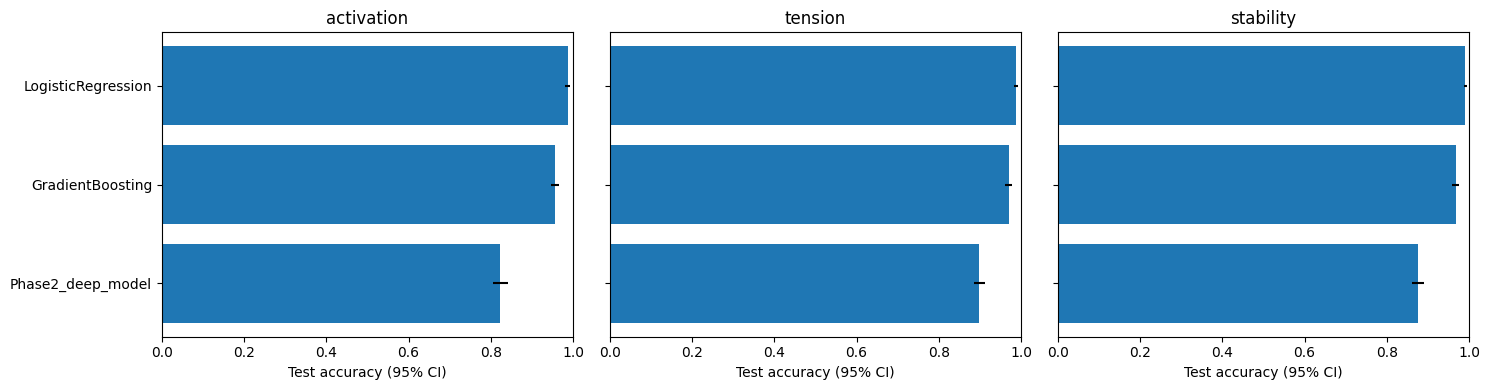


Hoàn tất. Kết quả đã lưu tại: /content/drive/MyDrive/motionemo_v10_raw_baseline


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, state in zip(axes, STATE_NAMES):
    sub = comparison_df[comparison_df['state'] == state].sort_values('test_accuracy')
    ax.barh(sub['model'], sub['test_accuracy'],
            xerr=[sub['test_accuracy'] - sub['ci_low'], sub['ci_high'] - sub['test_accuracy']])
    ax.set_title(state)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Test accuracy (95% CI)')
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'baseline_vs_phase2_comparison.png', dpi=180)
plt.show()

print('\nHoàn tất. Kết quả đã lưu tại:', OUTPUT_ROOT)